# Attention language model

Start from the same Tiny Shakespeare token stream as the bigram model, then inspect token embeddings before adding attention.

In [5]:
import random
import sys
from pathlib import Path

import torch
from torch import nn

repo_root = Path.cwd()
if not (repo_root / "data").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

from src.dataset import get_batch, load_tiny_shakespeare_tokens, split_token_stream

## Prepare token streams and batches

In [6]:
tokens, vocab, merges = load_tiny_shakespeare_tokens(repo_root / "data")
train_tokens, validation_tokens = split_token_stream(tokens)

vocab_size = len(vocab)
block_size = 8
batch_size = 32
n_embd = 32

random.seed(42)
x_batch, y_batch = get_batch(
    "train", train_tokens, validation_tokens, block_size, batch_size
)
x_batch = torch.tensor(x_batch, dtype=torch.long)
y_batch = torch.tensor(y_batch, dtype=torch.long)

## Model scaffold

In [7]:
class AttentionLanguageModel(nn.Module):
    def __init__(self, vocab_size, n_embd):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx):
        token_embeddings = self.token_embedding_table(idx)
        return self.lm_head(token_embeddings)


model = AttentionLanguageModel(vocab_size, n_embd)
token_embeddings = model.token_embedding_table(x_batch)
print(f"Token embedding shape (B, T, C): {tuple(token_embeddings.shape)}")

Token embedding shape (B, T, C): (32, 8, 32)


## TODO — first attention mechanics

1. Add positional embeddings so each token position has its own learned representation.
2. Implement one causal self-attention head over the `(B, T, C)` token embeddings.

Stop here before adding either piece.

In [8]:
# Positional embeddings
positional_embeddings = nn.Parameter(torch.zeros(1, block_size, n_embd))
# Add positional embeddings to token embeddings
token_embeddings += positional_embeddings
print(f"Token embedding shape after adding positional embeddings (B, T, C): {tuple(token_embeddings.shape)}")


Token embedding shape after adding positional embeddings (B, T, C): (32, 8, 32)


In [31]:
# Causal self-attention
import math
import torch
from torch import nn


head_size = 16

key = nn.Linear(n_embd, head_size, bias=False)
query = nn.Linear(n_embd, head_size, bias=False)
value = nn.Linear(n_embd, head_size, bias=False)

def causal_self_attention(x, mask=None):
    # Input: x, shape = [*, seq_len, n_embd]
    # mask: [*, seq_len, seq_len], used to avoid invalid values
    
    # Output: [*, seq_len, n_embd]
    
    batch_size, seq_len, n_embd = x.shape
    
    k = key(x).view(batch_size, seq_len, n_embd).permute(0, 2, 1) # [*, n_embd, seq_len]
    q = query(x).view(batch_size, seq_len, n_embd).permute(0, 2, 1) # [*, n_embd, seq_len]
    v = value(x).view(batch_size, seq_len, n_embd).permute(0, 2, 1) # [*, n_embd, seq_len]
    
    attention = torch.matmul(q, k.transpose(-1, -2)) / math.sqrt(n_embd) # [*, n_embd, seq_len]
    if mask is not None:
        attention = attention.masked_fill(mask == 0, -1e9)

k = key(token_embeddings)
q = query(token_embeddings)
v = value(token_embeddings)

attention = torch.matmul(q, k.transpose(-1, -2)) / math.sqrt(n_embd)

print(attention.shape)
print(attention[0, 0, :])
print(attention[0, 1, :])
print(attention[0, 2, :])

# mask = torch.ones(batch_size, seq_len, seq_len)
# attention = attention.masked_fill(mask == 0, -1e9)


torch.Size([32, 8, 8])
tensor([-0.0460,  0.0179, -0.6166, -0.3341, -0.2473, -0.0680, -0.2913, -0.1927],
       grad_fn=<SelectBackward0>)
tensor([ 0.1007, -0.0033, -0.2577, -0.4504, -0.2002,  0.0967, -0.1427,  0.1022],
       grad_fn=<SelectBackward0>)
tensor([-0.1825, -0.1164,  0.1385, -0.0089, -0.0120, -0.0389,  0.0305, -0.2330],
       grad_fn=<SelectBackward0>)


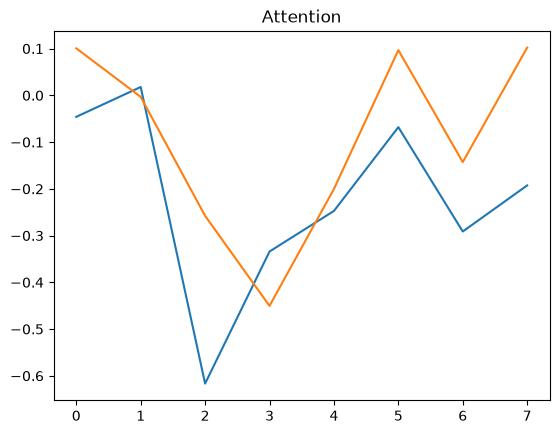

In [32]:
import matplotlib.pyplot as plt

k_plot = plt.plot
q_plot = plt.plot
v_plot = plt.plot

k_plot(k[0, 0].detach().numpy())
q_plot(q[0, 0].detach().numpy())
v_plot(v[0, 0].detach().numpy())

# new plot
a_1 = attention[0, 0].detach().numpy()
a_2 = attention[0, 1].detach().numpy()

plt.clf()

a_plot = plt.plot

plt.title('Attention')
a_plot(a_1)
a_plot(a_2)

# k_plot(k[0, 0].detach().numpy())
# q_plot(q[0, 0].detach().numpy())
# v_plot(v[0, 0].detach().numpy())